# ResNet-50 Skin Lesion Classifier — HAM10000

**Dataset:** HAM10000 · 7 classes: MEL, NV, BCC, AKIEC, BKL, DF, VASC  
**Augmentation:** Real images + GAN-generated / Reinhard-normalised images  
**Architecture:** ResNet-50 (ImageNet pre-trained, head replaced for 7-way classification)  
**Training:** Warm-up freeze (5 epochs) → full fine-tune, AdamW + CosineAnnealingLR, AMP mixed precision

---
## 1 · Imports & Config

In [1]:
# ── Standard library ───────────────────────────────────────────────────────
import random
import time
import logging
from pathlib import Path

# ── Numerical / ML ──────────────────────────────────────────────────────────
import numpy as np
import torch
import torch.nn as nn
from torch.amp import GradScaler
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import resnet50, ResNet50_Weights

# ── Data helpers ────────────────────────────────────────────────────────────
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    auc as sklearn_auc,
    confusion_matrix,
    f1_score,
)
from sklearn.preprocessing import label_binarize

# ── Progress / Plotting ─────────────────────────────────────────────────────
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ═══════════════════════════════════════════════════════════════════════════════
#  HYPER-PARAMETERS  (edit here only)
# ═══════════════════════════════════════════════════════════════════════════════
IMG_SIZE      = 224
BATCH_SIZE    = 8
EPOCHS        = 30
LR            = 1e-4
SEED          = 42
WARMUP_EPOCHS = 5          # freeze backbone for first N epochs

device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_CUDA = device.type == 'cuda'

CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AKIEC', 'BKL', 'DF', 'VASC']
NUM_CLASSES  = len(CLASS_NAMES)

# ── Paths ───────────────────────────────────────────────────────────────────
ROOT      = Path().cwd()                             # notebook lives in skin cancer/
DATA_ROOT = ROOT / 'dataset' / 'processed_images'
CKPT_DIR  = ROOT / 'checkpoints'
CKPT_PATH = CKPT_DIR / 'resnet50_best.pt'
LOG_PATH  = ROOT.parent / 'results' / 'logs' / 'training.log'

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

print(f'Device    : {device}')
print(f'Data root : {DATA_ROOT.resolve()}')
print(f'Checkpoint: {CKPT_PATH.resolve()}')
print(f'Log file  : {LOG_PATH.resolve()}')

Device    : cuda
Data root : C:\Users\shara\Desktop\paper_learning\skin cancer\dataset\processed_images
Checkpoint: C:\Users\shara\Desktop\paper_learning\skin cancer\checkpoints\resnet50_best.pt
Log file  : C:\Users\shara\Desktop\paper_learning\results\logs\training.log


In [2]:
# ── Reproducibility ─────────────────────────────────────────────────────────
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if USE_CUDA:
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False

seed_everything(SEED)
print('Seeds fixed \u2713')

Seeds fixed ✓


In [3]:
# ── Logger setup ────────────────────────────────────────────────────────────
def get_logger(log_path: Path) -> logging.Logger:
    logger = logging.getLogger('ResNet50')
    logger.setLevel(logging.INFO)
    logger.handlers.clear()  # avoid duplicate handlers on re-run

    fmt = logging.Formatter(
        '%(asctime)s | %(levelname)-8s | %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S',
    )

    fh = logging.FileHandler(str(log_path), mode='a', encoding='utf-8')
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    ch = logging.StreamHandler()
    ch.setFormatter(fmt)
    logger.addHandler(ch)

    return logger


logger = get_logger(LOG_PATH)
logger.info('=' * 70)
logger.info('ResNet-50 HAM10000 Training Run')
logger.info(
    f'Device={device} | IMG_SIZE={IMG_SIZE} | BATCH_SIZE={BATCH_SIZE}'
    f' | EPOCHS={EPOCHS} | LR={LR} | SEED={SEED}'
)
logger.info('=' * 70)

2026-07-28 20:43:28 | INFO     | ======================================================================
2026-07-28 20:43:28 | INFO     | ResNet-50 HAM10000 Training Run
2026-07-28 20:43:28 | INFO     | Device=cuda | IMG_SIZE=224 | BATCH_SIZE=8 | EPOCHS=30 | LR=0.0001 | SEED=42
2026-07-28 20:43:28 | INFO     | ======================================================================


---
## 2 · Dataset

In [4]:
# ── Transforms ──────────────────────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [5]:
# ── Dataset class ────────────────────────────────────────────────────────────
class SkinLesionDataset(Dataset):
    """Flat (filepath, label) dataset built from real/ and normalized/ sub-dirs."""

    def __init__(self, samples, transform=None):
        self.samples   = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


def build_sample_list(data_root: Path, class_names: list) -> list:
    """
    Scan processed_images/{cls}/real/ and normalized/ for every class.
    normalized/ is silently skipped if it does not exist (e.g. NV).
    """
    all_samples = []
    for cls_idx, cls_name in enumerate(class_names):
        cls_dir  = data_root / cls_name
        sub_dirs = [cls_dir / 'real']
        norm_dir = cls_dir / 'normalized'
        if norm_dir.exists():
            sub_dirs.append(norm_dir)
        else:
            print(f'  [INFO] {cls_name}/normalized/ not found - skipped (expected for NV)')

        for sub_dir in sub_dirs:
            if not sub_dir.exists():
                print(f'  [WARN] {sub_dir} does not exist - skipped')
                continue
            imgs = (
                list(sub_dir.glob('*.jpg'))
                + list(sub_dir.glob('*.jpeg'))
                + list(sub_dir.glob('*.png'))
            )
            all_samples.extend([(p, cls_idx) for p in imgs])

    return all_samples


# Build master list
all_samples = build_sample_list(DATA_ROOT, CLASS_NAMES)
all_labels  = [s[1] for s in all_samples]

print(f'\nTotal images found: {len(all_samples)}')
for i, cls in enumerate(CLASS_NAMES):
    cnt = sum(1 for lbl in all_labels if lbl == i)
    print(f'  {cls:>6}: {cnt}')

  [INFO] NV/normalized/ not found - skipped (expected for NV)

Total images found: 46935
     MEL: 6705
      NV: 6705
     BCC: 6705
   AKIEC: 6705
     BKL: 6705
      DF: 6705
    VASC: 6705


In [6]:
# ── Stratified 80 / 10 / 10 split ───────────────────────────────────────────
train_val_samples, test_samples, train_val_labels, test_labels = train_test_split(
    all_samples, all_labels,
    test_size=0.10, random_state=SEED, stratify=all_labels,
)

train_samples, val_samples, train_labels, val_labels = train_test_split(
    train_val_samples, train_val_labels,
    test_size=0.111,   # 0.111 × 0.90 ≈ 0.10 of total
    random_state=SEED, stratify=train_val_labels,
)


def print_split_counts(split_name, labels):
    print(f'\n{split_name} split ({len(labels)} total):')
    for i, cls in enumerate(CLASS_NAMES):
        cnt = labels.count(i)
        print(f'  {cls:>6}: {cnt}')


print_split_counts('Train', train_labels)
print_split_counts('Val',   val_labels)
print_split_counts('Test',  test_labels)

logger.info(
    f'Split sizes -> Train: {len(train_samples)}'
    f' | Val: {len(val_samples)} | Test: {len(test_samples)}'
)

# Log per-class counts for each split
for split_name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    for i, cls in enumerate(CLASS_NAMES):
        cnt = labels.count(i)
        logger.info(f'  [{split_name}] {cls}: {cnt}')

2026-07-28 20:43:39 | INFO     | Split sizes -> Train: 37552 | Val: 4689 | Test: 4694
2026-07-28 20:43:39 | INFO     |   [Train] MEL: 5365
2026-07-28 20:43:39 | INFO     |   [Train] NV: 5365
2026-07-28 20:43:39 | INFO     |   [Train] BCC: 5364
2026-07-28 20:43:39 | INFO     |   [Train] AKIEC: 5365
2026-07-28 20:43:39 | INFO     |   [Train] BKL: 5364
2026-07-28 20:43:39 | INFO     |   [Train] DF: 5365
2026-07-28 20:43:39 | INFO     |   [Train] VASC: 5364
2026-07-28 20:43:39 | INFO     |   [Val] MEL: 670
2026-07-28 20:43:39 | INFO     |   [Val] NV: 670
2026-07-28 20:43:39 | INFO     |   [Val] BCC: 670
2026-07-28 20:43:39 | INFO     |   [Val] AKIEC: 669
2026-07-28 20:43:39 | INFO     |   [Val] BKL: 670
2026-07-28 20:43:39 | INFO     |   [Val] DF: 670
2026-07-28 20:43:39 | INFO     |   [Val] VASC: 670
2026-07-28 20:43:39 | INFO     |   [Test] MEL: 670
2026-07-28 20:43:39 | INFO     |   [Test] NV: 670
2026-07-28 20:43:39 | INFO     |   [Test] BCC: 671
2026-07-28 20:43:39 | INFO     |   [Tes


Train split (37552 total):
     MEL: 5365
      NV: 5365
     BCC: 5364
   AKIEC: 5365
     BKL: 5364
      DF: 5365
    VASC: 5364

Val split (4689 total):
     MEL: 670
      NV: 670
     BCC: 670
   AKIEC: 669
     BKL: 670
      DF: 670
    VASC: 670

Test split (4694 total):
     MEL: 670
      NV: 670
     BCC: 671
   AKIEC: 671
     BKL: 671
      DF: 670
    VASC: 671


In [7]:
# ── WeightedRandomSampler ────────────────────────────────────────────────────
class_counts   = np.bincount(train_labels, minlength=NUM_CLASSES).astype(float)
class_weights  = 1.0 / np.where(class_counts == 0, 1.0, class_counts)
sample_weights = np.array([class_weights[lbl] for lbl in train_labels])

sampler = WeightedRandomSampler(
    weights     = torch.DoubleTensor(sample_weights),
    num_samples = len(train_samples),
    replacement = True,
)

# ── Datasets ────────────────────────────────────────────────────────────────
train_ds = SkinLesionDataset(train_samples, transform=train_transform)
val_ds   = SkinLesionDataset(val_samples,   transform=eval_transform)
test_ds  = SkinLesionDataset(test_samples,  transform=eval_transform)

# ── DataLoaders ─────────────────────────────────────────────────────────────
loader_kwargs = dict(pin_memory=True, num_workers=0) if USE_CUDA else {}

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          sampler=sampler, **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, **loader_kwargs)

print(f'Train batches: {len(train_loader)} | '
      f'Val batches: {len(val_loader)} | '
      f'Test batches: {len(test_loader)}')

Train batches: 4694 | Val batches: 587 | Test batches: 587


---
## 3 · Model

In [8]:
# ── Build ResNet-50 ───────────────────────────────────────────────────────────
def build_model(num_classes: int) -> nn.Module:
    model = resnet50(weights=ResNet50_Weights.DEFAULT)
    # ResNet-50 final feature dim is 2048 (not 1024 like DenseNet-121)
    in_features = model.fc.in_features  # 2048
    model.fc = nn.Linear(in_features, num_classes)
    return model


model = build_model(NUM_CLASSES).to(device)
logger.info(
    f'Model: ResNet-50 | fc in_features='
    f'{model.fc.in_features} -> out_features={NUM_CLASSES}'
)


# ── Freeze helpers ───────────────────────────────────────────────────────────
def freeze_backbone(model: nn.Module) -> None:
    """Freeze all layers except the fc head."""
    for name, param in model.named_parameters():
        param.requires_grad = name.startswith('fc')
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Backbone FROZEN   | trainable params: {trainable:,}')


def unfreeze_all(model: nn.Module) -> None:
    """Unfreeze every layer."""
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'  Backbone UNFROZEN | trainable params: {trainable:,}')


# ── Loss / Optimizer / Scheduler ────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler    = GradScaler('cuda', enabled=USE_CUDA)

# Start with backbone frozen (warm-up phase)
freeze_backbone(model)
print('\nModel built and ready \u2713')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\shara/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 34.2MB/s]
2026-07-28 20:43:56 | INFO     | Model: ResNet-50 | fc in_features=2048 -> out_features=7


  Backbone FROZEN   | trainable params: 14,343

Model built and ready ✓


---
## 4 · Training Loop

In [9]:
def run_epoch(loader, model, criterion, optimizer=None, scaler=None,
              phase='train', epoch=1, n_epochs=1):
    is_train = (phase == 'train')
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    running_loss = 0.0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        pbar = tqdm(
            loader,
            desc=f"[ResNet50] Epoch {epoch}/{n_epochs} | {phase}",
            leave=True
        )
        for imgs, labels in pbar:
            imgs, labels = imgs.to(device), labels.to(device)
            amp_enabled = USE_CUDA and is_train
            with torch.amp.autocast(device_type=device.type, enabled=amp_enabled):
                logits = model(imgs)
            loss = criterion(logits.float(), labels)

            if is_train:
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            running_loss += loss.item()
            total_loss   += loss.item() * imgs.size(0)
            preds         = logits.argmax(dim=1)
            correct      += (preds == labels).sum().item()
            total        += imgs.size(0)

            pbar.set_postfix(
                Loss=f"{running_loss / (pbar.n + 1):.4f}",
                Acc =f"{correct / total * 100:.2f}%"
            )

    return total_loss / total, correct / total



# ── Training loop ────────────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc  = 0.0
unfreeze_epoch = None


for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # Warm-up: unfreeze backbone after WARMUP_EPOCHS
    if epoch == WARMUP_EPOCHS + 1:
        logger.info(f'Epoch {epoch}: Unfreezing backbone for fine-tuning')
        unfreeze_epoch = epoch
        unfreeze_all(model)
        # Re-create optimizer to include all parameters at a reduced LR
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=LR * 0.1, weight_decay=1e-4
        )
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=EPOCHS - WARMUP_EPOCHS
        )

    train_loss, train_acc = run_epoch(
        train_loader, model, criterion,
        optimizer=optimizer, scaler=scaler, phase='train',
        epoch=epoch, n_epochs=EPOCHS,
    )
    val_loss, val_acc = run_epoch(
        val_loader, model, criterion, phase='val',
        epoch=epoch, n_epochs=EPOCHS,
    )
    scheduler.step()

    epoch_time = time.time() - epoch_start

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    log_msg = (
        f'Epoch [{epoch:02d}/{EPOCHS}]'
        f' | Time: {epoch_time:.1f}s'
        f' | Train Loss: {train_loss:.4f}  Train Acc: {train_acc*100:.2f}%'
        f' | Val Loss: {val_loss:.4f}  Val Acc: {val_acc*100:.2f}%'
    )
    logger.info(log_msg)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch':             epoch,
            'model_state_dict': model.state_dict(),
            'val_acc':           val_acc,
            'val_loss':          val_loss,
        }, CKPT_PATH)
        logger.info(f'  \u2713 Checkpoint saved (val_acc={val_acc*100:.2f}%)')

logger.info(f'Training complete. Best val accuracy: {best_val_acc*100:.2f}%')
print(f'\nTraining done! Best val accuracy: {best_val_acc*100:.2f}%')

[ResNet50] Epoch 1/30 | train: 100%|██████████| 4694/4694 [05:13<00:00, 14.97it/s, Acc=56.18%, Loss=1.3175]
[ResNet50] Epoch 1/30 | val: 100%|██████████| 587/587 [00:32<00:00, 17.92it/s, Acc=56.07%, Loss=1.2179]
2026-07-28 20:49:45 | INFO     | Epoch [01/30] | Time: 346.4s | Train Loss: 1.3175  Train Acc: 56.18% | Val Loss: 1.2159  Val Acc: 56.07%
2026-07-28 20:49:45 | INFO     |   ✓ Checkpoint saved (val_acc=56.07%)
[ResNet50] Epoch 2/30 | train: 100%|██████████| 4694/4694 [04:56<00:00, 15.82it/s, Acc=65.42%, Loss=1.0126]
[ResNet50] Epoch 2/30 | val: 100%|██████████| 587/587 [00:29<00:00, 20.13it/s, Acc=58.33%, Loss=1.1225]
2026-07-28 20:55:11 | INFO     | Epoch [02/30] | Time: 325.8s | Train Loss: 1.0126  Train Acc: 65.42% | Val Loss: 1.1210  Val Acc: 58.33%
2026-07-28 20:55:11 | INFO     |   ✓ Checkpoint saved (val_acc=58.33%)
[ResNet50] Epoch 3/30 | train: 100%|██████████| 4694/4694 [04:24<00:00, 17.75it/s, Acc=68.48%, Loss=0.9207]
[ResNet50] Epoch 3/30 | val: 100%|██████████| 587/

  Backbone UNFROZEN | trainable params: 23,522,375


[ResNet50] Epoch 6/30 | train: 100%|██████████| 4694/4694 [09:03<00:00,  8.64it/s, Acc=84.00%, Loss=0.4692]
[ResNet50] Epoch 6/30 | val: 100%|██████████| 587/587 [00:29<00:00, 19.95it/s, Acc=91.75%, Loss=0.2866]
2026-07-28 21:19:24 | INFO     | Epoch [06/30] | Time: 572.8s | Train Loss: 0.4692  Train Acc: 84.00% | Val Loss: 0.2861  Val Acc: 91.75%
2026-07-28 21:19:24 | INFO     |   ✓ Checkpoint saved (val_acc=91.75%)
[ResNet50] Epoch 7/30 | train: 100%|██████████| 4694/4694 [09:02<00:00,  8.65it/s, Acc=91.47%, Loss=0.2486]
[ResNet50] Epoch 7/30 | val: 100%|██████████| 587/587 [00:29<00:00, 19.88it/s, Acc=93.15%, Loss=0.2056]
2026-07-28 21:28:56 | INFO     | Epoch [07/30] | Time: 572.4s | Train Loss: 0.2486  Train Acc: 91.47% | Val Loss: 0.2048  Val Acc: 93.15%
2026-07-28 21:28:56 | INFO     |   ✓ Checkpoint saved (val_acc=93.15%)
[ResNet50] Epoch 8/30 | train: 100%|██████████| 4694/4694 [09:03<00:00,  8.64it/s, Acc=93.67%, Loss=0.1837]
[ResNet50] Epoch 8/30 | val: 100%|██████████| 587/

KeyboardInterrupt: 

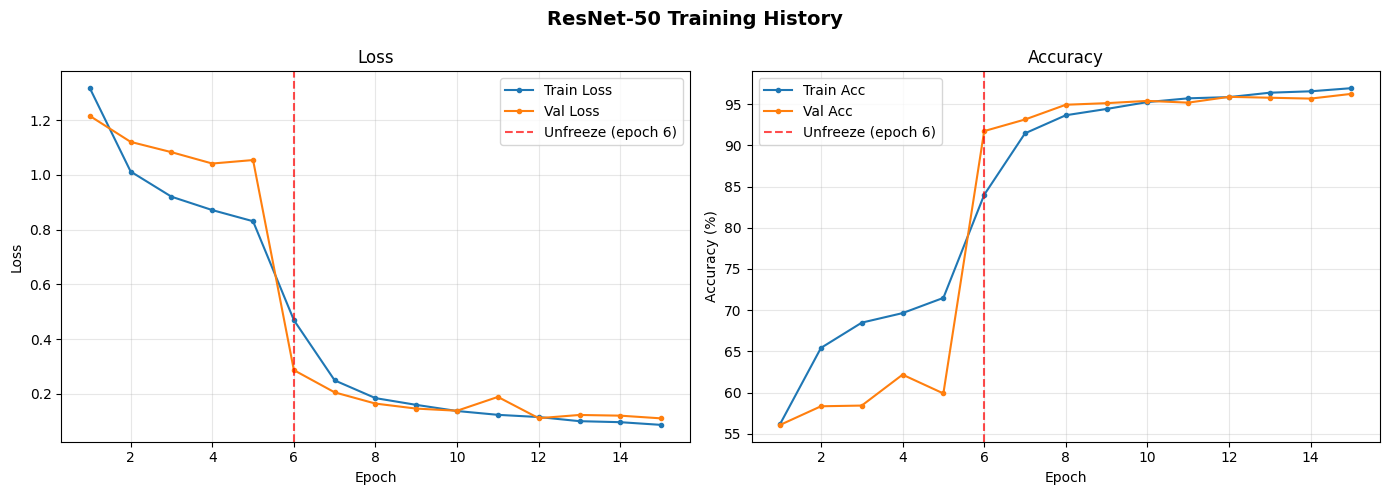

Saved -> resnet50_training_curves.png


In [11]:
# ── Training history plot ────────────────────────────────────────────────────
epochs_range = range(1, 15 + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ResNet-50 Training History', fontsize=14, fontweight='bold')

# Loss subplot
axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', markersize=3)
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='o', markersize=3)
if unfreeze_epoch is not None:
    axes[0].axvline(x=unfreeze_epoch, color='red', linestyle='--', alpha=0.7,
                    label=f'Unfreeze (epoch {unfreeze_epoch})')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy subplot
axes[1].plot(epochs_range, [a * 100 for a in history['train_acc']], label='Train Acc', marker='o', markersize=3)
axes[1].plot(epochs_range, [a * 100 for a in history['val_acc']],   label='Val Acc',   marker='o', markersize=3)
if unfreeze_epoch is not None:
    axes[1].axvline(x=unfreeze_epoch, color='red', linestyle='--', alpha=0.7,
                    label=f'Unfreeze (epoch {unfreeze_epoch})')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('resnet50_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> resnet50_training_curves.png')

---
## 5 · Evaluation on Test Set

In [12]:
# ── Load best checkpoint ─────────────────────────────────────────────────────
ckpt = torch.load(CKPT_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
logger.info(
    f'Loaded checkpoint from epoch {ckpt["epoch"]} '
    f'(val_acc={ckpt["val_acc"]*100:.2f}%)'
)
print(f'Checkpoint loaded: epoch {ckpt["epoch"]}, val_acc={ckpt["val_acc"]*100:.2f}%')

2026-07-28 22:46:48 | INFO     | Loaded checkpoint from epoch 15 (val_acc=96.27%)


Checkpoint loaded: epoch 15, val_acc=96.27%


In [13]:
# ── Run inference on test set ────────────────────────────────────────────────
model.eval()
all_preds       = []
all_labels_test = []
all_probs       = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc='[ResNet50] Evaluating test set', leave=True)
    for imgs, labels in pbar:
        imgs   = imgs.to(device)
        logits = model(imgs)
        probs  = torch.softmax(logits.float(), dim=1)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels_test.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds       = np.array(all_preds)
all_labels_test = np.array(all_labels_test)
all_probs       = np.array(all_probs)

# ── Overall accuracy ─────────────────────────────────────────────────────────
test_acc = (all_preds == all_labels_test).mean()
logger.info(f'Test Accuracy: {test_acc*100:.2f}%')
print(f'\nTest Accuracy: {test_acc*100:.2f}%')

[ResNet50] Evaluating test set: 100%|██████████| 587/587 [00:31<00:00, 18.87it/s]
2026-07-28 22:47:23 | INFO     | Test Accuracy: 96.04%



Test Accuracy: 96.04%


In [14]:
# ── Classification report ────────────────────────────────────────────────────
report = classification_report(
    all_labels_test, all_preds,
    target_names=CLASS_NAMES,
    digits=4
)
print('\nClassification Report:')
print(report)
logger.info('\n' + report)

# ── Macro / Weighted F1 ──────────────────────────────────────────────────────
macro_f1    = f1_score(all_labels_test, all_preds, average='macro')
weighted_f1 = f1_score(all_labels_test, all_preds, average='weighted')
logger.info(f'Macro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}')
print(f'Macro F1   : {macro_f1:.4f}')
print(f'Weighted F1: {weighted_f1:.4f}')

2026-07-28 22:47:26 | INFO     | 
              precision    recall  f1-score   support

         MEL     0.9286    0.9313    0.9300       670
          NV     0.9057    0.9463    0.9255       670
         BCC     0.9805    0.9762    0.9783       671
       AKIEC     0.9879    0.9732    0.9805       671
         BKL     0.9288    0.9136    0.9211       671
          DF     0.9955    0.9881    0.9918       670
        VASC     0.9985    0.9940    0.9963       671

    accuracy                         0.9604      4694
   macro avg     0.9608    0.9604    0.9605      4694
weighted avg     0.9608    0.9604    0.9605      4694

2026-07-28 22:47:26 | INFO     | Macro F1: 0.9605 | Weighted F1: 0.9605



Classification Report:
              precision    recall  f1-score   support

         MEL     0.9286    0.9313    0.9300       670
          NV     0.9057    0.9463    0.9255       670
         BCC     0.9805    0.9762    0.9783       671
       AKIEC     0.9879    0.9732    0.9805       671
         BKL     0.9288    0.9136    0.9211       671
          DF     0.9955    0.9881    0.9918       670
        VASC     0.9985    0.9940    0.9963       671

    accuracy                         0.9604      4694
   macro avg     0.9608    0.9604    0.9605      4694
weighted avg     0.9608    0.9604    0.9605      4694

Macro F1   : 0.9605
Weighted F1: 0.9605


2026-07-28 22:48:37 | INFO     |   AUC [MEL]: 0.9971
2026-07-28 22:48:37 | INFO     |   AUC [NV]: 0.9965
2026-07-28 22:48:37 | INFO     |   AUC [BCC]: 0.9996
2026-07-28 22:48:37 | INFO     |   AUC [AKIEC]: 0.9995
2026-07-28 22:48:37 | INFO     |   AUC [BKL]: 0.9961
2026-07-28 22:48:37 | INFO     |   AUC [DF]: 0.9999
2026-07-28 22:48:37 | INFO     |   AUC [VASC]: 0.9999
2026-07-28 22:48:37 | INFO     | Macro AUC: 0.9984



Per-class AUC-ROC:
     MEL: 0.9971
      NV: 0.9965
     BCC: 0.9996
   AKIEC: 0.9995
     BKL: 0.9961
      DF: 0.9999
    VASC: 0.9999
  Macro AUC: 0.9984


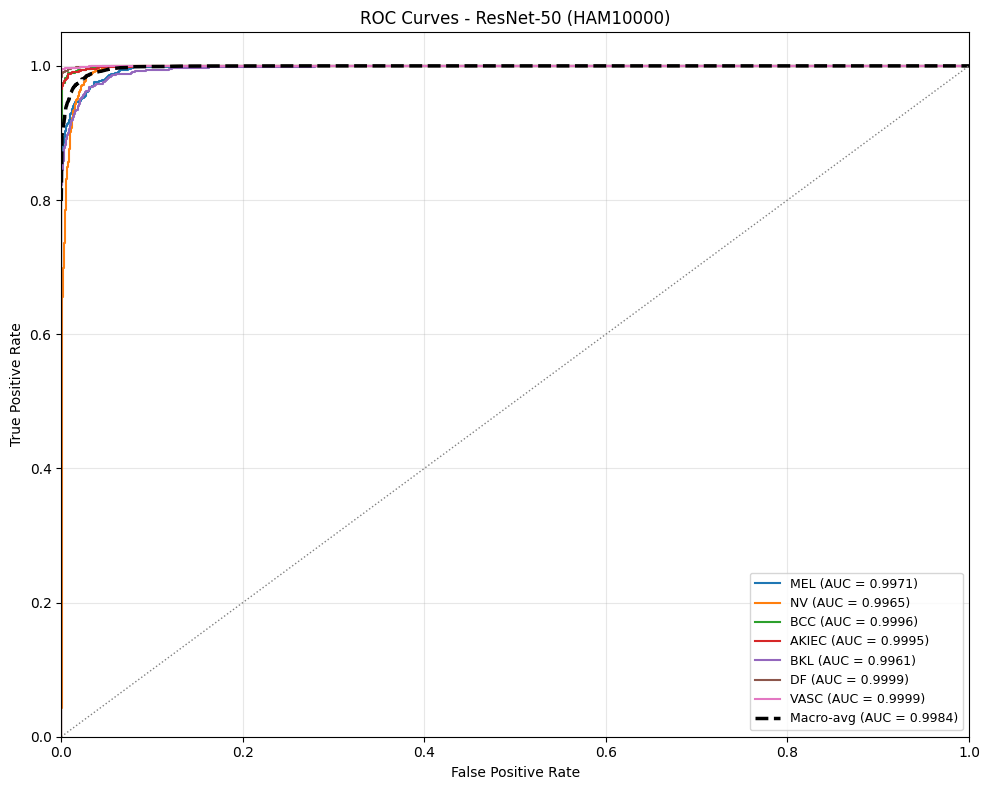

Saved -> resnet50_roc_curves.png


In [15]:
# ── Per-class AUC-ROC + ROC curves ──────────────────────────────────────────
labels_bin = label_binarize(all_labels_test, classes=list(range(NUM_CLASSES)))

# Per-class AUC
per_class_auc = roc_auc_score(labels_bin, all_probs, multi_class='ovr', average=None)
macro_auc     = roc_auc_score(labels_bin, all_probs, multi_class='ovr', average='macro')

print('\nPer-class AUC-ROC:')
for cls, auc_val in zip(CLASS_NAMES, per_class_auc):
    print(f'  {cls:>6}: {auc_val:.4f}')
    logger.info(f'  AUC [{cls}]: {auc_val:.4f}')
print(f'  Macro AUC: {macro_auc:.4f}')
logger.info(f'Macro AUC: {macro_auc:.4f}')

# ── Plot all 7 ROC curves + macro-average on one figure ─────────────────────
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 8))

fpr_all, tpr_all = {}, {}
for i, (cls, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    fpr_all[i]  = fpr
    tpr_all[i]  = tpr
    ax.plot(fpr, tpr, color=color, lw=1.5,
            label=f'{cls} (AUC = {per_class_auc[i]:.4f})')

# Macro-average curve (interpolated)
all_fpr  = np.unique(np.concatenate([fpr_all[i] for i in range(NUM_CLASSES)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(NUM_CLASSES):
    mean_tpr += np.interp(all_fpr, fpr_all[i], tpr_all[i])
mean_tpr /= NUM_CLASSES
ax.plot(all_fpr, mean_tpr, color='black', lw=2.5, linestyle='--',
        label=f'Macro-avg (AUC = {macro_auc:.4f})')

ax.plot([0, 1], [0, 1], color='grey', linestyle=':', lw=1)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - ResNet-50 (HAM10000)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resnet50_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved -> resnet50_roc_curves.png')

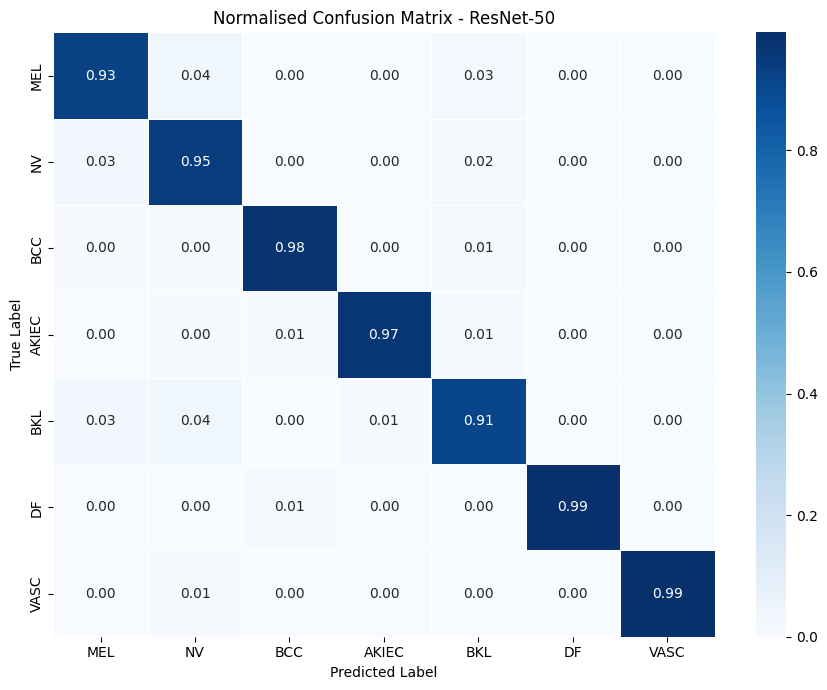

2026-07-28 22:50:03 | INFO     | Evaluation complete.


Saved -> resnet50_confusion_matrix.png


In [16]:
# ── Normalised confusion matrix ──────────────────────────────────────────────
cm      = confusion_matrix(all_labels_test, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalise by true label

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax,
    linewidths=0.5,
)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Normalised Confusion Matrix - ResNet-50')
plt.tight_layout()
plt.savefig("resnet50_confusion_matrix.png" , dpi=150 , bbox_inches="tight")
plt.show()
print("Saved -> resnet50_confusion_matrix.png")
logger.info('Evaluation complete.')